In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data.csv")

In [3]:
df.head(5)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [4]:
df.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [5]:
df.apply(lambda col: col.duplicated().sum())

Make                 11866
Model                10999
Year                 11886
Engine Fuel Type     11903
Engine HP            11557
Engine Cylinders     11904
Transmission Type    11909
Driven_Wheels        11910
Number of Doors      11910
Market Category      11842
Vehicle Size         11911
Vehicle Style        11898
highway MPG          11855
city mpg             11845
Popularity           11866
MSRP                  5865
dtype: int64

In [6]:
df.drop_duplicates(inplace=True)
print(f"Rows Remaining: {len(df)}")

Rows Remaining: 11199


In [7]:
print(df.duplicated().sum())

0


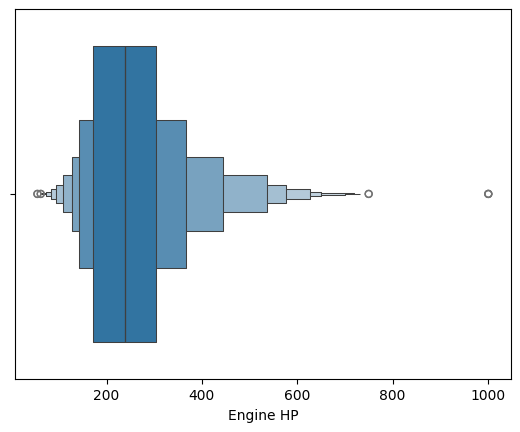

In [69]:
sns.boxenplot(x=df['Engine HP'])
plt.show()

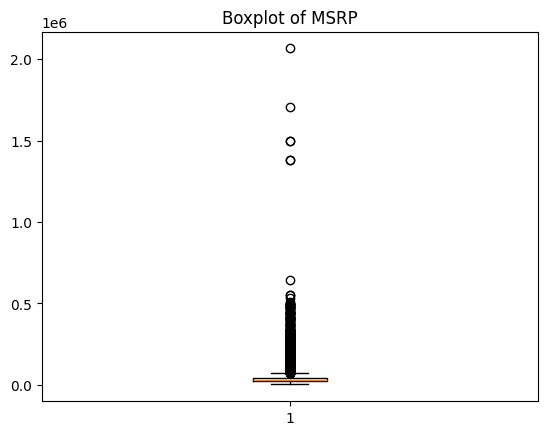

In [9]:
plt.boxplot(df['MSRP'])
plt.title('Boxplot of MSRP')
plt.show()

In [10]:
df['Engine Fuel Type'].value_counts()

Engine Fuel Type
regular unleaded                                6658
premium unleaded (required)                     1956
premium unleaded (recommended)                  1392
flex-fuel (unleaded/E85)                         887
diesel                                           150
electric                                          66
flex-fuel (premium unleaded required/E85)         53
flex-fuel (premium unleaded recommended/E85)      26
flex-fuel (unleaded/natural gas)                   6
natural gas                                        2
Name: count, dtype: int64

In [11]:
print(df['Engine Fuel Type'].isnull().sum())
df['Engine Fuel Type'] = df['Engine Fuel Type'].fillna('regular unleaded')

3


In [12]:
print(df['Engine HP'].isnull().sum())

median_hp = df.groupby('Make')['Engine HP'].transform('median')
df['Engine HP'] = df['Engine HP'].fillna(median_hp)

global_median = df['Engine HP'].median()
df['Engine HP'] = df['Engine HP'].fillna(global_median)

69


In [13]:
print(df['Engine Cylinders'].isnull().sum())

median_cly = df.groupby('Make')['Engine Cylinders'].transform('median')
df['Engine Cylinders'] = df['Engine Cylinders'].fillna(median_cly)

30


In [14]:
print(df['Number of Doors'].isnull().sum())

mode_door = df['Number of Doors'].mode()[0]
df['Number of Doors'] = df['Number of Doors'].fillna(mode_door)

6


In [15]:
df.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        0
Engine HP               0
Engine Cylinders        0
Transmission Type       0
Driven_Wheels           0
Number of Doors         0
Market Category      3376
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [16]:
print(df['Market Category'].isnull().sum())
df['Market Category'] = df['Market Category'].fillna('Unknown')

3376


### Here is the top 10 expensive car and bugatti is kind of outlier because its price is very high compare to others

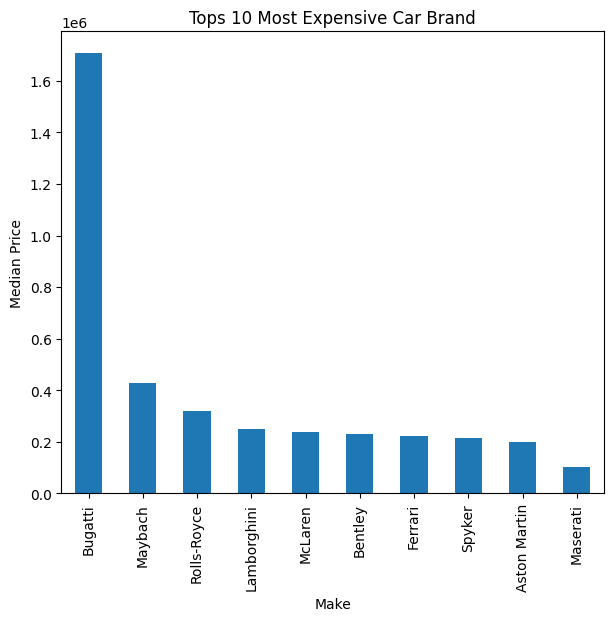

In [17]:
plt.figure(figsize=(7,6))
df.groupby('Make')['MSRP'].median().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Tops 10 Most Expensive Car Brand")
plt.ylabel("Median Price")
plt.show()

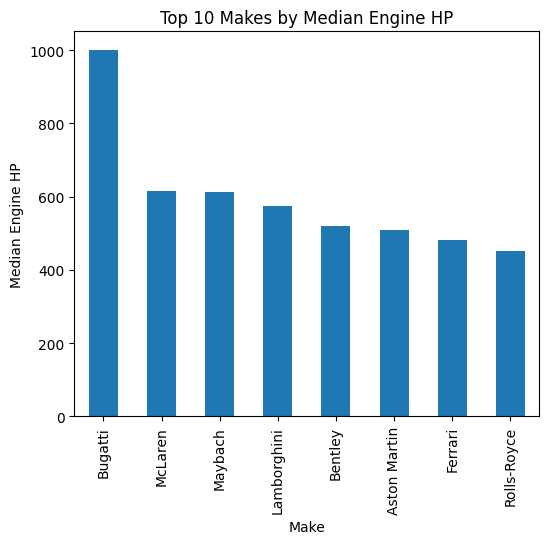

In [70]:
plt.figure(figsize=(6,5))
df.groupby('Make')['Engine HP'].median().sort_values(ascending=False).head(8).plot(kind='bar')
plt.title('Top 10 Makes by Median Engine HP')
plt.ylabel('Median Engine HP')
plt.show()

### Here price distribution is right skewd means there is outliers of very high price and we cleary saw that there is many low price cars and very few high price cars

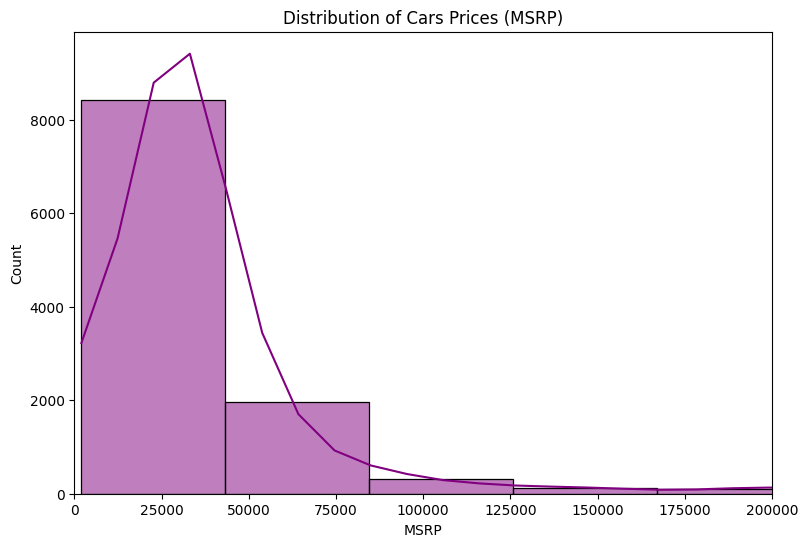

In [72]:
plt.figure(figsize=(9,6))
sns.histplot(df['MSRP'], bins=50, kde='True', color='purple')
plt.title('Distribution of Cars Prices (MSRP)')
plt.xlim(0, 200000)
plt.show()

In [21]:
df.head(2)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650


### This heatmap shows the correlation between numerical features, where darker colors indicate stronger relationships.

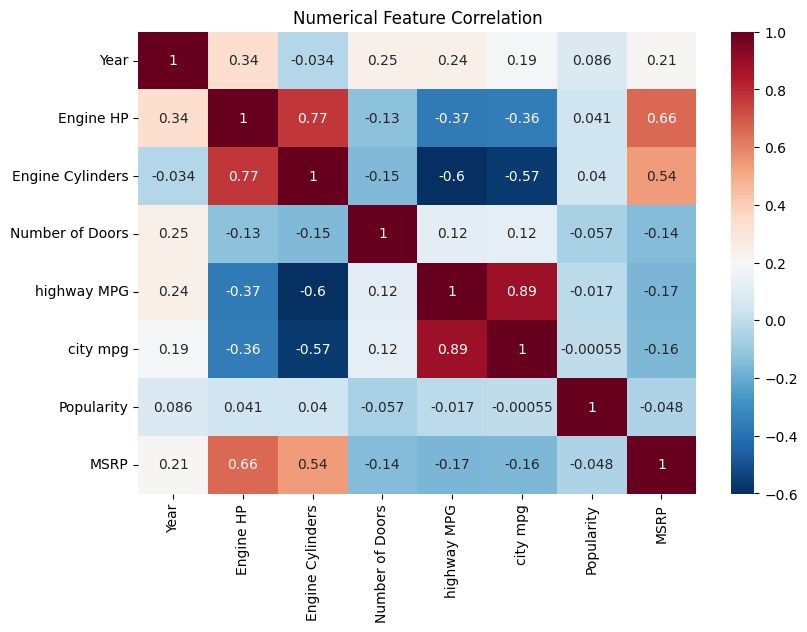

In [45]:
num_cols = ['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors', 'highway MPG', 'city mpg', 'Popularity', 'MSRP']
plt.figure(figsize=(9,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='RdBu_r')
plt.title("Numerical Feature Correlation")
plt.show()

### Here we can see that when engine_hp is increasing price is also increasing but for luxury cars price is increasing very high

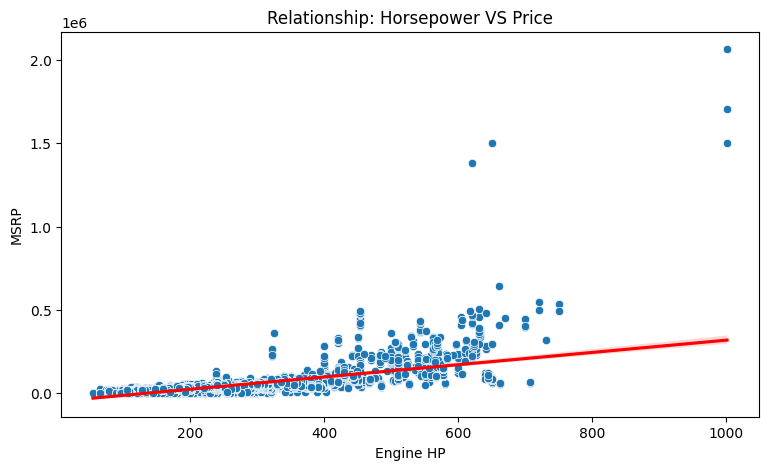

In [44]:
plt.figure(figsize=(9,5))
sns.scatterplot(x='Engine HP', y='MSRP', data=df)

plt.title("Relationship: Horsepower VS Price")
plt.xlabel("Engine Horsepower (HP)")
plt.ylabel("Price (MSRP)")

sns.regplot(x='Engine HP', y='MSRP', data=df, scatter=False, color='red')

plt.show()

### Here we can see that after year 2000 there is huge jump in MSRP 

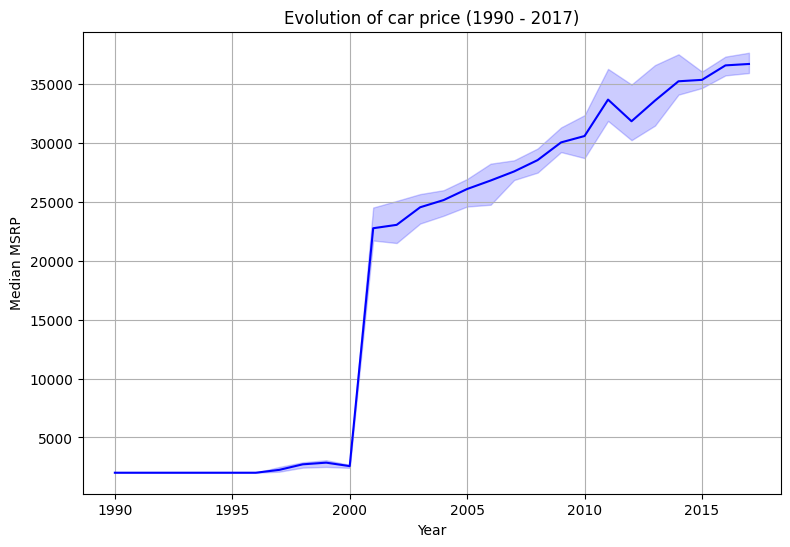

In [43]:
plt.figure(figsize=(9,6))
sns.lineplot(x='Year', y='MSRP', data=df, estimator='median', color='blue')
plt.title("Evolution of car price (1990 - 2017)")
plt.ylabel("Median MSRP")
plt.grid(True,)
plt.show()

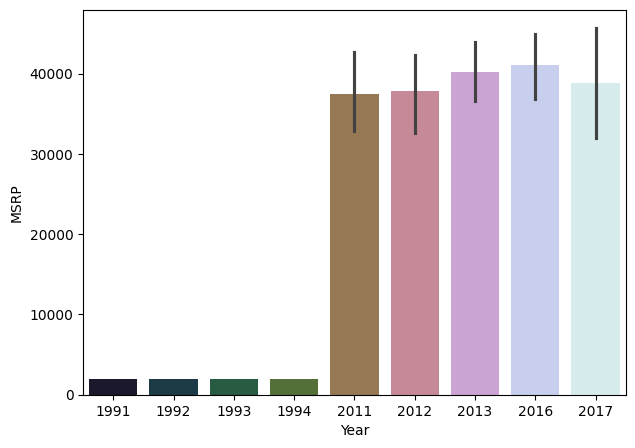

In [68]:
plt.figure(figsize=(7,5))
sns.barplot(x='Year', y='MSRP', data=df.head(50), palette='cubehelix')
plt.show()